In [1]:
import requests
import json
import time
import os
import pandas as pd
import numpy as np

import zipfile
from io import BytesIO

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

In [2]:
PATH = '/content/drive/MyDrive/Colab Notebooks/Проектная школа 1 курс/TOP-5-ECO-Analysys/Копия PyPI_vulnerabilities.json'

with open(PATH, 'r') as f:
    all_data = json.load(f)

print("Данные загружены!")

Данные загружены!


In [3]:
def normalize_osv_data(data):
    """
    Превращает сырые OSV JSON-записи в две плоские таблицы:
    - vulns_df: одна строка = одна уязвимость
    - affected_df: одна строка = один затронутый пакет
    """
    vulns_list = []
    affected_list = []

    for vuln in data:
        # Извлечение severity
        db_specific = vuln.get('database_specific', {})
        if not isinstance(db_specific, dict):
            db_specific = {}

        severity_score = np.nan
        severity_string = ''

        # прямой CVSS
        for sev in vuln.get('severity', []):
            if sev.get('type') == 'CVSS_V3':
                try:
                    severity_score = float(sev.get('score', 0))
                except:
                    pass

        # GHSA severity строка -> число
        if pd.isna(severity_score):
            severity_string = db_specific.get('severity', '')
            severity_map = {
                'CRITICAL': 9.5, 'HIGH': 7.5,
                'MODERATE': 5.5, 'MEDIUM': 5.5, 'LOW': 2.5
            }
            severity_score = severity_map.get(severity_string.upper(), np.nan)

        # Таблица уязвимостей
        vuln_record = {
            'id': vuln.get('id'),
            'schema_version': vuln.get('schema_version'),
            'published': vuln.get('published'),
            'modified': vuln.get('modified'),
            'withdrawn': vuln.get('withdrawn'),
            'summary': vuln.get('summary', '').strip() if vuln.get('summary') else '',
            'details': vuln.get('details', '').strip() if vuln.get('details') else '',
            'aliases': '|'.join(vuln.get('aliases', [])),
            'upstream': '|'.join(vuln.get('upstream', [])),
            'references_count': len(vuln.get('references', [])),
            'cvss_score': severity_score,
            'severity_string': severity_string,
            'cwe_ids': '|'.join(db_specific.get('cwe_ids', [])) if isinstance(db_specific.get('cwe_ids'), list) else '',
            'affected_count': len(vuln.get('affected', [])),
        }

        # Категория severity
        if pd.isna(severity_score):
            vuln_record['severity_category'] = 'UNKNOWN'
        elif severity_score >= 9.0:
            vuln_record['severity_category'] = 'CRITICAL'
        elif severity_score >= 7.0:
            vuln_record['severity_category'] = 'HIGH'
        elif severity_score >= 4.0:
            vuln_record['severity_category'] = 'MEDIUM'
        elif severity_score >= 0.1:
            vuln_record['severity_category'] = 'LOW'
        else:
            vuln_record['severity_category'] = 'NONE'

        # Проверка на fix
        has_any_fix = False
        for aff in vuln.get('affected', []):
            for rng in aff.get('ranges', []):
                for evt in rng.get('events', []):
                    if 'fixed' in evt and evt['fixed']:
                        has_any_fix = True
                        break
        vuln_record['has_any_fix'] = has_any_fix

        vulns_list.append(vuln_record)

        # Таблица затронутых пакетов
        for aff_idx, aff in enumerate(vuln.get('affected', [])):
            pkg = aff.get('package', {})

            aff_record = {
                'vulnerability_id': vuln.get('id'),
                'package_ecosystem': pkg.get('ecosystem', ''),
                'package_name': pkg.get('name', ''),
                'package_purl': pkg.get('purl', ''),
                'affected_index': aff_idx,
            }

            # Есть ли fix в этом affected
            has_fix = False
            fix_versions = []
            for rng in aff.get('ranges', []):
                for evt in rng.get('events', []):
                    if 'fixed' in evt and evt['fixed']:
                        has_fix = True
                        fix_versions.append(evt['fixed'])

            aff_record['has_fix'] = has_fix
            aff_record['fix_versions'] = '|'.join(fix_versions) if fix_versions else None
            aff_record['versions_count'] = len(aff.get('versions', []))

            affected_list.append(aff_record)

    # Сборка DataFrame
    vulns_df = pd.DataFrame(vulns_list)
    affected_df = pd.DataFrame(affected_list)

    # Конвертация дат
    for col in ['published', 'modified', 'withdrawn', 'nvd_published_at', 'github_reviewed_at']:
        if col in vulns_df.columns:
            vulns_df[col] = pd.to_datetime(vulns_df[col], format='mixed', errors='coerce', utc=True)

    # Вычисляемые поля
    vulns_df['days_to_modify'] = (vulns_df['modified'] - vulns_df['published']).dt.days
    vulns_df['is_withdrawn'] = vulns_df['withdrawn'].notna()
    vulns_df['publication_year'] = vulns_df['published'].dt.year
    vulns_df['publication_month'] = vulns_df['published'].dt.month

    # Источник (по префиксу ID)
    vulns_df['source'] = vulns_df['id'].str.split('-').str[0]

    return vulns_df, affected_df



print("Нормализация данных...")
vulns_df, affected_df = normalize_osv_data(all_data)

print(f"  vulns_df: {vulns_df.shape[0]:,} строк, {vulns_df.shape[1]} колонок")
print(f"  affected_df: {affected_df.shape[0]:,} строк, {affected_df.shape[1]} колонок")

print(f"\n Первые 5 строк vulns_df:")
display(vulns_df[['id', 'schema_version', 'published', 'withdrawn', 'summary',
       'details', 'aliases', 'upstream', 'references_count',
       'cvss_score', 'severity_string']].head())

display(vulns_df[['cwe_ids',
       'affected_count', 'severity_category', 'has_any_fix', 'days_to_modify',
       'is_withdrawn', 'publication_year', 'publication_month', 'source']].head())


print(f"\n Источники (source):")
print(vulns_df['source'].value_counts())

print(f"\n Severity категории:")
print(vulns_df['severity_category'].value_counts())

print(f"\n Доля с CVSS: {vulns_df['cvss_score'].notna().mean()*100:.1f}%")
print(f" Доля с fix: {vulns_df['has_any_fix'].mean()*100:.1f}%")

Нормализация данных...
  vulns_df: 19,564 строк, 21 колонок
  affected_df: 24,900 строк, 8 колонок

 Первые 5 строк vulns_df:


,id,schema_version,published,withdrawn,summary,details,aliases,upstream,references_count,cvss_score,severity_string
0,GHSA-227r-w5j2-6243,1.7.3,2025-03-20 12:32:41+00:00,NaT,InvokeAI Arbitrary File Deletion vulnerability,"In invoke-ai/invokeai version v5.0.2, the web ...",CVE-2024-11042,,4,9.5,CRITICAL
1,GHSA-22c2-9gwg-mj59,1.7.3,2025-05-20 18:01:52+00:00,NaT,Langroid has a Code Injection vulnerability in...,### Summary\n[LanceDocChatAgent](https://githu...,CVE-2025-46725,,4,7.5,HIGH
2,GHSA-22cc-w7xm-rfhx,1.7.3,2024-02-28 21:30:20+00:00,NaT,Mezzanine allows attackers to bypass access co...,An issue in Mezzanine v6.0.0 allows attackers ...,CVE-2024-25170,,5,5.5,MODERATE
3,GHSA-22fp-mf44-f2mq,1.7.3,2025-04-18 20:24:07+00:00,NaT,youtube-dl vulnerable to file system modificat...,#### Description\nThis advisory follows the se...,,,7,7.5,HIGH
4,GHSA-22gh-3r9q-xf38,1.7.5,2021-09-20 19:53:30+00:00,NaT,Lacking Protection against HTTP Request Smuggl...,"### Impact\n\nIn mitmproxy 7.0.2 and below, a ...",CVE-2021-39214|PYSEC-2021-328,,4,9.5,CRITICAL


,cwe_ids,affected_count,severity_category,has_any_fix,days_to_modify,is_withdrawn,publication_year,publication_month,source
0,CWE-20|CWE-22|CWE-73,1,CRITICAL,True,209.0,False,2025,3,GHSA
1,CWE-94,1,HIGH,True,0.0,False,2025,5,GHSA
2,,1,MEDIUM,False,281.0,False,2024,2,GHSA
3,CWE-434|CWE-669,1,HIGH,False,291.0,False,2025,4,GHSA
4,CWE-444,1,CRITICAL,True,1635.0,False,2021,9,GHSA



 Источники (source):
source
MAL      11156
GHSA      5088
PYSEC     3312
OSV          8
Name: count, dtype: int64

 Severity категории:
severity_category
UNKNOWN     14476
MEDIUM       2071
HIGH         1949
CRITICAL      633
LOW           435
Name: count, dtype: int64

 Доля с CVSS: 26.0%
 Доля с fix: 37.9%


In [4]:
affected_df.head()

,vulnerability_id,package_ecosystem,package_name,package_purl,affected_index,has_fix,fix_versions,versions_count
0,GHSA-227r-w5j2-6243,PyPI,invokeai,pkg:pypi/invokeai,0,True,5.3.0rc1,145
1,GHSA-22c2-9gwg-mj59,PyPI,langroid,pkg:pypi/langroid,0,True,0.53.15,448
2,GHSA-22cc-w7xm-rfhx,PyPI,mezzanine,pkg:pypi/mezzanine,0,False,None,138
3,GHSA-22fp-mf44-f2mq,PyPI,youtube-dl,pkg:pypi/youtube-dl,0,False,None,482
4,GHSA-22gh-3r9q-xf38,PyPI,mitmproxy,pkg:pypi/mitmproxy,0,True,7.0.3,48


In [5]:
# Сводная таблица: source × severity_category
crosstab = pd.crosstab(vulns_df['source'], vulns_df['severity_category'])
print("Таблица сопряжения: source × severity_category")
print(crosstab)

Таблица сопряжения: source × severity_category
severity_category  CRITICAL  HIGH  LOW  MEDIUM  UNKNOWN
source                                                 
GHSA                    633  1949  435    2071        0
MAL                       0     0    0       0    11156
OSV                       0     0    0       0        8
PYSEC                     0     0    0       0     3312


In [6]:
# Берём только MAL-записи
mal = vulns_df[vulns_df['source'] == 'MAL']

print("MAL - ВРЕДОНОСНЫЕ ПАКЕТЫ")

print()

print(f"Всего записей: {len(mal):,}")
print(f"С fix: {mal['has_any_fix'].sum():,}")
print(f"С отзывом (withdrawn): {mal['is_withdrawn'].sum():,}")
print(f"Среднее references: {mal['references_count'].mean():.1f}")
print()

# По годам
print("По годам:")
print(mal['publication_year'].value_counts().sort_index())
print()

# Примеры summary
print("Примеры summary:")
for s in mal['summary'].sample(10, random_state=1):
    print(f"  -- {s}")

MAL - ВРЕДОНОСНЫЕ ПАКЕТЫ

Всего записей: 11,156
С fix: 0
С отзывом (withdrawn): 2
Среднее references: 1.1

По годам:
publication_year
2022      20
2023    6468
2024    2646
2025    1245
2026     777
Name: count, dtype: int64

Примеры summary:
  -- Malicious code in libmcpingstudy (PyPI)
  -- Malicious code in prometheus-quicker-analysis (PyPI)
  -- Malicious code in tpproofreplace (PyPI)
  -- Malicious code in httpniggerblackcocksontopfr (PyPI)
  -- Malicious code in spiderai (PyPI)
  -- Malicious code in toollgtb (PyPI)
  -- Malicious code in esqstudyguiping (PyPI)
  -- Malicious code in superre (PyPI)
  -- Malicious code in mattermost-airflow (PyPI)
  -- Malicious code in prof-tg-gdghho-qu (PyPI)


**Здесь видно, что данные, которые пришли с этой базы - просто вредоносные файлы, поэтому для дальнейшего анализа они бесполезны**

In [7]:
# Берём только PYSEC
pysec = vulns_df[vulns_df['source'] == 'PYSEC'].copy()


print("PYSEC — PYPI ADVISORY DATABASE")
print()
print(f"Всего записей: {len(pysec):,}")
print(f"С fix: {pysec['has_any_fix'].sum():,} ({pysec['has_any_fix'].mean()*100:.1f}%)")
print(f"С CVSS: {pysec['cvss_score'].notna().sum():,}")
print(f"Среднее references: {pysec['references_count'].mean():.1f}")
print()

# По годам
print("По годам:")
print(pysec['publication_year'].value_counts().sort_index())
print()

# Есть ли алиасы (связь с CVE/GHSA)?
pysec['has_aliases'] = pysec['aliases'].notna() & (pysec['aliases'] != '')
print(f"Имеют алиасы: {pysec['has_aliases'].sum():,} ({pysec['has_aliases'].mean()*100:.1f}%)")

# Сколько ссылаются на GHSA?
pysec['has_ghsa'] = pysec['aliases'].str.contains('GHSA', na=False)
print(f"Из них с GHSA: {pysec['has_ghsa'].sum():,}")

# Сколько ссылаются на CVE?
pysec['has_cve'] = pysec['aliases'].str.contains('CVE', na=False)
print(f"Из них с CVE: {pysec['has_cve'].sum():,}")

print()
print("Примеры summary:")
for s in pysec['summary'].sample(5, random_state=2):
    print(f"  --{s[:120]}")

PYSEC — PYPI ADVISORY DATABASE

Всего записей: 3,312
С fix: 2,959 (89.3%)
С CVSS: 0
Среднее references: 3.7

По годам:
publication_year
2005      1
2006      8
2007      4
2008     14
2009     13
2010     32
2011     27
2012     41
2013     45
2014    116
2015     42
2016     41
2017    148
2018    154
2019    251
2020    325
2021    889
2022    515
2023    312
2024    259
2025     72
2026      3
Name: count, dtype: int64

Имеют алиасы: 2,983 (90.1%)
Из них с GHSA: 2,870
Из них с CVE: 2,980

Примеры summary:
  --
  --
  --
  --
  --


In [8]:
ghsa = vulns_df[vulns_df['source'] == 'GHSA'].copy()
pysec = vulns_df[vulns_df['source'] == 'PYSEC'].copy()

# Строим индекс: alias -> список GHSA id
alias_to_ghsa = {}
for _, row in ghsa.iterrows():
    for alias in str(row['aliases']).split('|'):
        alias = alias.strip()
        if alias:
            alias_to_ghsa.setdefault(alias, []).append(row['id'])

# Ищем пересечения: для каждого PYSEC проверяем его aliases
pairs = []
for _, p_row in pysec.iterrows():
    p_aliases = [a.strip() for a in str(p_row['aliases']).split('|') if a.strip()]
    found_ghsa_ids = set()

    for alias in p_aliases:
        if alias in alias_to_ghsa:
            found_ghsa_ids.update(alias_to_ghsa[alias])

    for g_id in found_ghsa_ids:
        g_row = ghsa[ghsa['id'] == g_id].iloc[0]
        pairs.append({
            'PYSEC_id': p_row['id'],
            'GHSA_id': g_id,
            'PYSEC_modified': p_row['modified'],
            'GHSA_modified': g_row['modified'],
            'GHSA_newer': g_row['modified'] > p_row['modified']
        })

pairs_df = pd.DataFrame(pairs)
print(f"Найдено пар: {len(pairs_df)}")
print(f"GHSA новее: {pairs_df['GHSA_newer'].sum()} ({pairs_df['GHSA_newer'].mean()*100:.0f}%)")
print(f"PYSEC новее: {(~pairs_df['GHSA_newer']).sum()}")

Найдено пар: 2884
GHSA новее: 2711 (94%)
PYSEC новее: 173


In [9]:
# Смотрим все OSV-записи
osv = vulns_df[vulns_df['source'] == 'OSV']

print("OSV - 8 ЗАПИСЕЙ")
for _, row in osv.iterrows():
    print(f"\nID: {row['id']}")
    print(f"  Summary: {str(row['summary'])[:150]}")
    print(f"  Has fix: {row['has_any_fix']}")
    print(f"  Aliases: {row['aliases'][:150] if pd.notna(row['aliases']) else '—'}")
    print(f"  Year: {row['publication_year']}")

OSV - 8 ЗАПИСЕЙ

ID: OSV-2021-1809
  Summary: Heap-buffer-overflow in ujson.cpython-38-x86_64-linux-gnu.so
  Has fix: True
  Aliases: 
  Year: 2022

ID: OSV-2021-449
  Summary: UNKNOWN READ in std::pair<absl::lts_NUMBER_02_25::container_internal::raw_hash_set<absl::lts_NUM
  Has fix: True
  Aliases: 
  Year: 2021

ID: OSV-2021-955
  Summary: Stack-buffer-overflow in Buffer_AppendIndentUnchecked
  Has fix: True
  Aliases: 
  Year: 2021

ID: OSV-2022-1074
  Summary: Invalid-free in _dealloc
  Has fix: True
  Aliases: 
  Year: 2022

ID: OSV-2022-715
  Summary: Segv on unknown address in jpeg_read_scanlines
  Has fix: True
  Aliases: 
  Year: 2022

ID: OSV-2023-885
  Summary: UNKNOWN READ in bytes1_char_at
  Has fix: True
  Aliases: 
  Year: 2023

ID: OSV-2025-409
  Summary: Heap-buffer-overflow in libodbc.so.2
  Has fix: False
  Aliases: 
  Year: 2025

ID: OSV-2025-500
  Summary: UNKNOWN READ in getUShort
  Has fix: True
  Aliases: 
  Year: 2025


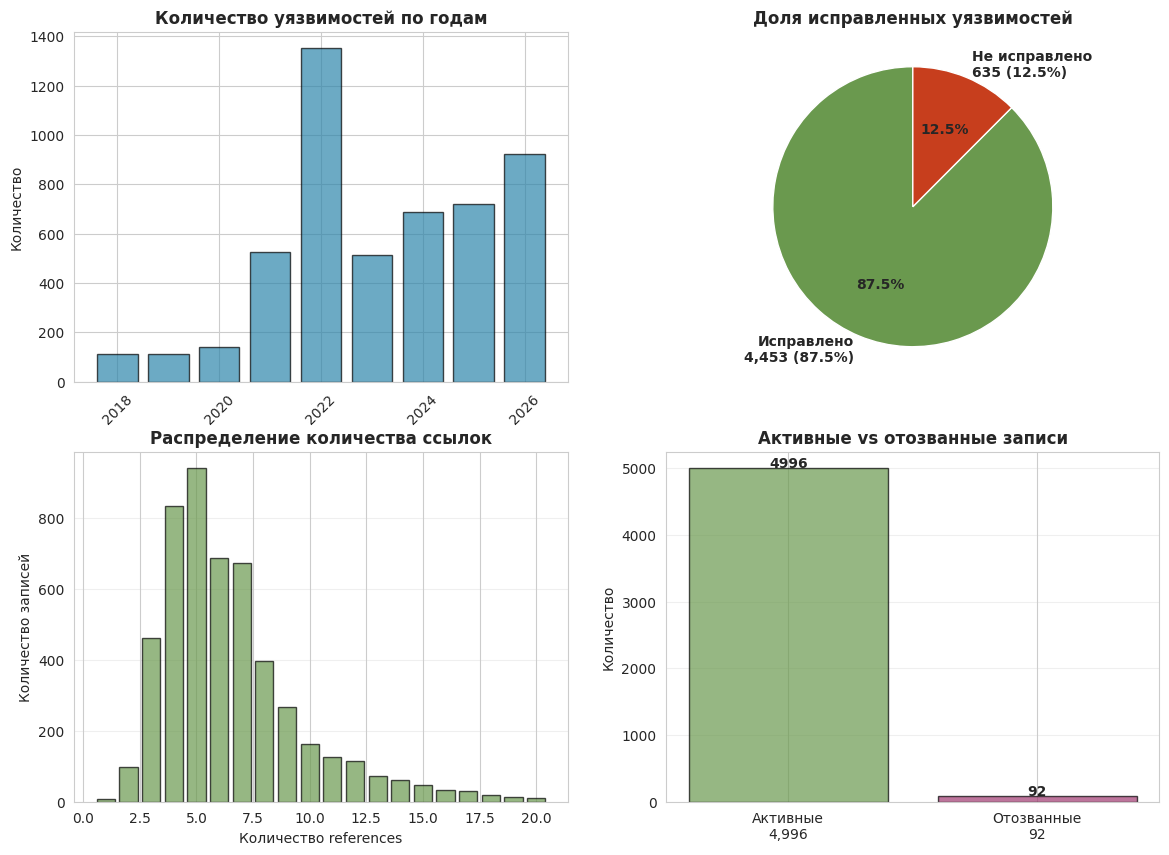

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Выделяем GHSA - базу из гитхаба
ghsa = vulns_df[vulns_df['source'] == 'GHSA'].copy()

# Создаём фигуру с несколькими сабплотами
fig = plt.figure(figsize=(14, 10))

# Настройка стиля
sns.set_style("whitegrid")
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E']

ax1 = fig.add_subplot(2, 2, 1)
year_counts = ghsa['publication_year'].value_counts().sort_index()
ax1.bar(year_counts.index, year_counts.values, color=colors[0], edgecolor='black', alpha=0.7)
ax1.set_title('Количество уязвимостей по годам', fontsize=12, fontweight='bold')
ax1.set_ylabel('Количество')
ax1.tick_params(axis='x', rotation=45)


ax2 = fig.add_subplot(2, 2, 2)
fix_counts = [ghsa['has_any_fix'].sum(), len(ghsa) - ghsa['has_any_fix'].sum()]
labels = [f'Исправлено\n{fix_counts[0]:,} ({fix_counts[0]/len(ghsa)*100:.1f}%)',
          f'Не исправлено\n{fix_counts[1]:,} ({fix_counts[1]/len(ghsa)*100:.1f}%)']
colors_pie = ['#6A994E', '#C73E1D']
ax2.pie(fix_counts, labels=labels, autopct='%1.1f%%', colors=colors_pie, startangle=90,
        textprops={'fontsize': 10, 'fontweight': 'bold'})
ax2.set_title('Доля исправленных уязвимостей', fontsize=12, fontweight='bold')


ax6 = fig.add_subplot(2, 2, 3)
ref_counts = ghsa['references_count'].value_counts().sort_index()
# Показываем только до 20 ссылок для наглядности
ref_counts_filtered = ref_counts[ref_counts.index <= 20]
ax6.bar(ref_counts_filtered.index, ref_counts_filtered.values, color=colors[4], edgecolor='black', alpha=0.7)
ax6.set_xlabel('Количество references')
ax6.set_ylabel('Количество записей')
ax6.set_title('Распределение количества ссылок', fontsize=12, fontweight='bold')
ax6.grid(axis='y', alpha=0.3)



ax7 = fig.add_subplot(2, 2, 4)
withdrawn_counts = [len(ghsa) - ghsa['is_withdrawn'].sum(), ghsa['is_withdrawn'].sum()]
labels7 = [f'Активные\n{withdrawn_counts[0]:,}', f'Отозванные\n{withdrawn_counts[1]:,}']
colors7 = ['#6A994E', '#A23B72']
ax7.bar(labels7, withdrawn_counts, color=colors7, edgecolor='black', alpha=0.7)
ax7.set_ylabel('Количество')
ax7.set_title('Активные vs отозванные записи', fontsize=12, fontweight='bold')
for i, v in enumerate(withdrawn_counts):
    ax7.text(i, v + 10, str(v), ha='center', fontweight='bold')
ax7.grid(axis='y', alpha=0.3)

In [11]:
plt.show()# SEVERITY: PIE + BAR
fig1 = make_subplots(rows=1, cols=2, specs=[[{'type':'pie'}, {'type':'bar'}]],
                     subplot_titles=('Доли', 'Количество'))

sev_counts = ghsa['severity_category'].value_counts()
colors = {'CRITICAL':'#FF0000', 'HIGH':'#FF6B35', 'MEDIUM':'#FFC107', 'LOW':'#4CAF50'}

fig1.add_trace(go.Pie(labels=sev_counts.index, values=sev_counts.values,
                      marker=dict(colors=[colors[c] for c in sev_counts.index]),
                      hole=0.3, textinfo='percent+label'), row=1, col=1)

fig1.add_trace(go.Bar(x=sev_counts.index, y=sev_counts.values,
                      marker=dict(color=[colors[c] for c in sev_counts.index]),
                      text=sev_counts.values, textposition='outside'), row=1, col=2)

fig1.update_layout(title="1. Распределение severity (GHSA)", height=450, showlegend=False)
fig1.show()

In [12]:
# Количество и средний CVSS по годам
yearly = ghsa.groupby('publication_year').agg(
    count=('id', 'count'),
    avg_cvss=('cvss_score', 'mean')
).reset_index()
yearly = yearly[yearly['publication_year'].between(2018, 2027)]

fig = go.Figure()

# Бар — количество
fig.add_trace(go.Bar(
    x=yearly['publication_year'],
    y=yearly['count'],
    name='Количество уязвимостей',
    marker_color='lightblue',
    yaxis='y1'
))

# Линия — средний CVSS
fig.add_trace(go.Scatter(
    x=yearly['publication_year'],
    y=yearly['avg_cvss'],
    mode='lines+markers',
    name='Средний CVSS',
    marker=dict(size=12, color='red'),
    line=dict(width=3, color='red'),
    yaxis='y2'
))

fig.update_layout(
    title="Количество уязвимостей и средний CVSS по годам",
    xaxis_title="Год публикации",
    yaxis=dict(title="Количество", side='left'),
    yaxis2=dict(title="Средний CVSS", overlaying='y', side='right', range=[0, 10]),
    height=500,
    hovermode='x unified'
)

fig.show()

In [13]:
import plotly.express as px

# Время модификации по severity (только те, у кого есть дата модификации)
data = ghsa[ghsa['days_to_modify'].notna()].copy()
# Убираем выбросы для наглядности (обрежем по 95-му перцентилю)
cutoff = data['days_to_modify'].quantile(0.95)
data = data[data['days_to_modify'] <= cutoff]

fig = px.box(
    data,
    x='severity_category',
    y='days_to_modify',
    color='severity_category',
    title="Время модификации по severity (без выбросов >95%)",
    labels={'days_to_modify': 'Дней до модификации', 'severity_category': 'Severity'},
    category_orders={'severity_category': ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']}
)

fig.update_layout(height=500, showlegend=False)
fig.show()

In [14]:
# Топ уязвимых пакетов из GHSA
ghsa_ids = ghsa['id'].tolist()
ghsa_affected = affected_df[affected_df['vulnerability_id'].isin(ghsa_ids)]

top = ghsa_affected['package_name'].value_counts().head(15)

# Группируем tensorflow-варианты
tf_mask = ghsa_affected['package_name'].str.contains('tensorflow', case=False, na=False)
tf_affected = ghsa_affected[tf_mask]

# Считаем уникальные уязвимости
tf_unique_vulns = tf_affected['vulnerability_id'].nunique()

# Считаем fix rate двумя методами
# Метод 1: any() — хоть одна строка с fix
tf_fix_any = tf_affected.groupby('vulnerability_id')['has_fix'].any().mean() * 100
# Метод 2: all() — все строки с fix
tf_fix_all = tf_affected.groupby('vulnerability_id')['has_fix'].all().mean() * 100


# Топ-10 с двумя методами fix rate
ghsa_affected_clean = ghsa_affected.copy()
ghsa_affected_clean.loc[tf_mask, 'package_name'] = 'tensorflow (все версии)'

top_clean = ghsa_affected_clean['package_name'].value_counts().head(10)

print("Топ-10 пакетов (tensorflow объединён):")
for i, (pkg, count) in enumerate(top_clean.items(), 1):
    pkg_data = ghsa_affected_clean[ghsa_affected_clean['package_name'] == pkg]
    unique = pkg_data['vulnerability_id'].nunique()

    # Два метода fix rate для пакета
    fix_any = pkg_data.groupby('vulnerability_id')['has_fix'].any().mean() * 100
    fix_all = pkg_data.groupby('vulnerability_id')['has_fix'].all().mean() * 100

    print(f"  {i:2d}. {pkg:30s} {unique:4d} уязв., fix_any: {fix_any:.0f}%, fix_all: {fix_all:.0f}%")

Топ-10 пакетов (tensorflow объединён):
   1. tensorflow (все версии)         435 уязв., fix_any: 100%, fix_all: 100%
   2. django                          152 уязв., fix_any: 99%, fix_all: 99%
   3. salt                             67 уязв., fix_any: 100%, fix_all: 85%
   4. plone                           100 уязв., fix_any: 82%, fix_all: 77%
   5. ansible                          66 уязв., fix_any: 97%, fix_all: 97%
   6. apache-airflow                  111 уязв., fix_any: 100%, fix_all: 100%
   7. open-webui                       91 уязв., fix_any: 75%, fix_all: 75%
   8. apache-superset                  68 уязв., fix_any: 78%, fix_all: 78%
   9. nova                             53 уязв., fix_any: 94%, fix_all: 92%
  10. mlflow                           67 уязв., fix_any: 73%, fix_all: 73%


In [15]:
# Подготовка данных
ghsa_ids = ghsa['id'].tolist()
ghsa_affected = affected_df[affected_df['vulnerability_id'].isin(ghsa_ids)].copy()

# Объединяем tensorflow-семейство
tf_mask = ghsa_affected['package_name'].str.contains('tensorflow', case=False, na=False)
ghsa_affected.loc[tf_mask, 'package_name'] = 'tensorflow (все версии)'



# ===== ТОП-15 ПАКЕТОВ (уникальные уязвимости) =====
pkg_stats = ghsa_affected.groupby('package_name').agg(
    unique_vulns=('vulnerability_id', 'nunique'),
    fix_rate=('has_fix', 'mean')
).reset_index()
top15 = pkg_stats.nlargest(15, 'unique_vulns')

fig3 = go.Figure(go.Bar(x=top15['unique_vulns'], y=top15['package_name'], orientation='h',
                         marker=dict(color=top15['unique_vulns'], colorscale='Reds'),
                         text=top15['unique_vulns'], textposition='outside'))
fig3.update_layout(title="Топ-15 пакетов по уникальным уязвимостям", height=550,
                   yaxis={'categoryorder':'total ascending'}, xaxis_title="Уникальных уязвимостей")
fig3.show()

# ===== HEATMAP SEVERITY × ГОД =====
heat = pd.crosstab(ghsa[ghsa['publication_year']>=2018]['publication_year'], ghsa['severity_category'])
fig5 = px.imshow(heat.T, title="Тепловая карта severity по годам",
                 labels=dict(x="Год", y="Severity", color="Кол-во"), aspect="auto", color_continuous_scale="YlOrRd")
fig5.update_layout(height=400)
fig5.show()

# ===== FIX RATE ПО SEVERITY (stacked bar) =====
fix_stats = ghsa.groupby('severity_category').agg(total=('id','count'), fixed=('has_any_fix','sum')).reset_index()
fix_stats['unfixed'] = fix_stats['total'] - fix_stats['fixed']
fix_stats['fix_rate'] = (fix_stats['fixed']/fix_stats['total']*100).round(1)

fig6 = go.Figure()
fig6.add_trace(go.Bar(x=fix_stats['severity_category'], y=fix_stats['fixed'], name='Исправлено',
                      marker_color='#4CAF50', text=fix_stats['fix_rate'].apply(lambda x: f'{x}%'), textposition='inside'))
fig6.add_trace(go.Bar(x=fix_stats['severity_category'], y=fix_stats['unfixed'], name='Не исправлено',
                      marker_color='#FF5252'))
fig6.update_layout(title="Доля исправленных по severity", height=450, barmode='stack', yaxis_title="Количество")
fig6.show()

# ===== ГИСТОГРАММА ДНЕЙ ДО МОДИФИКАЦИИ =====
mod_data = ghsa[ghsa['days_to_modify'].notna() & (ghsa['days_to_modify']<=1000)]['days_to_modify']
fig7 = go.Figure()
fig7.add_trace(go.Histogram(x=mod_data, nbinsx=50, marker_color='#2196F3', opacity=0.7))
for name, val, color in [('Медиана', mod_data.median(), 'red'), ('Среднее', mod_data.mean(), 'green')]:
    fig7.add_vline(x=val, line_dash="dash", line_color=color, annotation_text=f"{name}: {val:.0f} дн.")
fig7.update_layout(title="Распределение времени до модификации", height=450,
                   xaxis_title="Дней", yaxis_title="Количество")
fig7.show()

# ===== СРЕДНИЙ CVSS ПО ПАКЕТАМ (ТОП-15) =====
pkg_cvss = ghsa_affected.merge(ghsa[['id','cvss_score']], left_on='vulnerability_id', right_on='id')
pkg_cvss_agg = pkg_cvss.groupby('package_name').agg(avg_cvss=('cvss_score','mean'), count=('vulnerability_id','nunique')).reset_index()
top_cvss = pkg_cvss_agg[pkg_cvss_agg['count']>=10].nlargest(15, 'avg_cvss')

fig8 = go.Figure(go.Bar(x=top_cvss['avg_cvss'], y=top_cvss['package_name'], orientation='h',
                         marker=dict(color=top_cvss['avg_cvss'], colorscale='Reds'),
                         text=top_cvss['avg_cvss'].round(1), textposition='outside'))
fig8.update_layout(title="Топ-15 пакетов по среднему CVSS (мин. 10 уязвимостей)", height=500,
                   yaxis={'categoryorder':'total ascending'}, xaxis_title="Средний CVSS", xaxis_range=[0,10])
fig8.show()


# ===== ТОП-10 CWE =====
ghsa['primary_cwe'] = ghsa['cwe_ids'].str.split('|').str[0]
cwe_top = ghsa['primary_cwe'].value_counts().head(10)
fig11 = go.Figure(go.Bar(x=cwe_top.values, y=cwe_top.index, orientation='h',
                          marker=dict(color=cwe_top.values, colorscale='Blues'),
                          text=cwe_top.values, textposition='outside'))
fig11.update_layout(title="Топ-10 типов уязвимостей (CWE)", height=400,
                    yaxis={'categoryorder':'total ascending'}, xaxis_title="Количество")
fig11.show()

# ===== FIX RATE ПО ПАКЕТАМ (ТОП-15 С ХУДШИМ %) =====
worst_fix = pkg_stats[pkg_stats['unique_vulns']>=10].nsmallest(15, 'fix_rate')
fig12 = go.Figure(go.Bar(x=worst_fix['fix_rate']*100, y=worst_fix['package_name'], orientation='h',
                          marker=dict(color=worst_fix['fix_rate']*100, colorscale='Reds_r'),
                          text=worst_fix['fix_rate'].apply(lambda x: f'{x*100:.0f}%'), textposition='outside'))
fig12.update_layout(title="Пакеты с худшим процентом исправлений (мин. 10 уязвимостей)", height=500,
                    yaxis={'categoryorder':'total descending'}, xaxis_title="% исправленных", xaxis_range=[0,100])
fig12.show()
